# Haberdashery Sales Analysis 2023-2026
## Exploratory Data Analysis of daily sales from a family-owned business located in the oil industry zone of Veracruz, Mexico.

### Context
- Family business established in 2000
- Located in an oil industry zone (PEMEX, Braskem IDESA and other enterprises workers area)
- Closed on Saturdays
- A second branch was opened in August-September 2025

## Data Cleaning
The raw data presented the following issues that were addressed before analysis:

- Currency format ($1,000) converted to numeric values
- Date column converted from string to datetime format
- Saturday rows removed (business is closed on Saturdays)
- Missing values filled with median
- Typos in 2 records corrected by cross-referencing physical records

- 1 outlier pending verification (Nov 20, 2024 - $8,000)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv ("haberdashery_analysis.csv")
print(df.head())
df["cantidad vendida"] = df["cantidad vendida"].str.replace("$", "", regex=False)
df["cantidad vendida"] = df["cantidad vendida"].str.replace(",", "", regex=False)
df["cantidad vendida"] = pd.to_numeric(df["cantidad vendida"], errors="coerce")

df["fecha"] = pd.to_datetime(df["fecha"], dayfirst=True)

df["dia_semana"] = df["fecha"].dt.day_name()

df = df[df["dia_semana"] != "Saturday"].copy()

df["cantidad vendida"] = df["cantidad vendida"].fillna(df["cantidad vendida"].median())

print(df.shape)
print(df.isnull().sum())
print(df.head())

      fecha cantidad vendida
0  1/1/2023               $0
1  2/1/2023             $600
2  3/1/2023             $700
3  4/1/2023           $1,000
4  5/1/2023           $1,000
(978, 3)
fecha               0
cantidad vendida    0
dia_semana          0
dtype: int64
       fecha  cantidad vendida dia_semana
0 2023-01-01               0.0     Sunday
1 2023-01-02             600.0     Monday
2 2023-01-03             700.0    Tuesday
3 2023-01-04            1000.0  Wednesday
4 2023-01-05            1000.0   Thursday


In [2]:
#agregar la columna año
df["year"] = df["fecha"].dt.year
print(df)
df = df.rename(columns={
    "fecha": "date",
    "cantidad vendida": "daily_sales",
    "dia_semana": "weekday"
})

print(df.head())


          fecha  cantidad vendida dia_semana  year
0    2023-01-01               0.0     Sunday  2023
1    2023-01-02             600.0     Monday  2023
2    2023-01-03             700.0    Tuesday  2023
3    2023-01-04            1000.0  Wednesday  2023
4    2023-01-05            1000.0   Thursday  2023
...         ...               ...        ...   ...
1134 2026-06-10             850.0  Wednesday  2026
1135 2026-06-11             900.0   Thursday  2026
1136 2026-06-12             600.0     Friday  2026
1138 2026-06-14             500.0     Sunday  2026
1139 2026-06-15            1550.0     Monday  2026

[978 rows x 4 columns]
        date  daily_sales    weekday  year
0 2023-01-01          0.0     Sunday  2023
1 2023-01-02        600.0     Monday  2023
2 2023-01-03        700.0    Tuesday  2023
3 2023-01-04       1000.0  Wednesday  2023
4 2023-01-05       1000.0   Thursday  2023


In [3]:
print(df.groupby("year")["daily_sales"].sum())
df["month"] = df["date"].dt.month
print(df.head())

year
2023    295201.0
2024    275950.0
2025    307000.0
2026    122150.0
Name: daily_sales, dtype: float64
        date  daily_sales    weekday  year  month
0 2023-01-01          0.0     Sunday  2023      1
1 2023-01-02        600.0     Monday  2023      1
2 2023-01-03        700.0    Tuesday  2023      1
3 2023-01-04       1000.0  Wednesday  2023      1
4 2023-01-05       1000.0   Thursday  2023      1


## Annual Sales Analysis
Comparison of average daily sales per year to evaluate overall business performance.
Note: 2026 data only covers January–June.

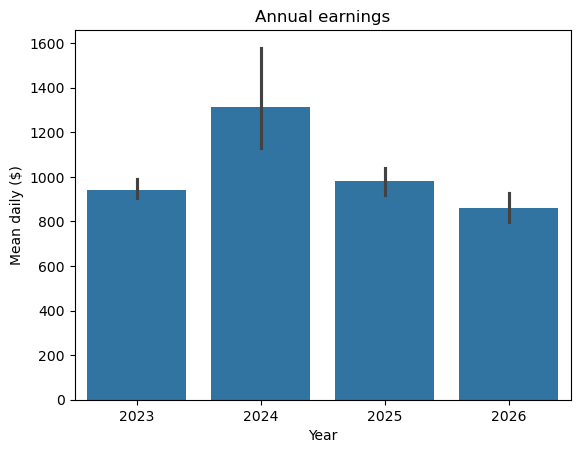

In [4]:
sns.barplot(data=df, x="year", y="daily_sales", estimator="mean")
plt.title("Annual earnings")
plt.xlabel("Year")
plt.ylabel("Mean daily ($)")
plt.show()

## Seasonality Analysis
Monthly average sales to identify seasonal patterns throughout the year.

**Key finding:** October, November and December are consistently the strongest months across all years. April and May are the weakest months, likely due to lower consumer activity mid-year.

month
1      951.401869
2     1017.525773
3      928.125000
4      805.844156
5      748.101266
6      803.076923
7     1005.450000
8      891.139241
9     1018.181818
10    1291.358025
11    1281.578947
12    1512.062500
Name: daily_sales, dtype: float64


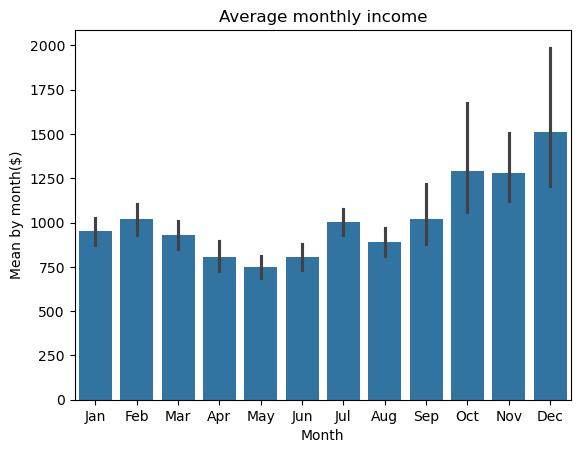

In [5]:
#Average sales by month
print(df.groupby("month")["daily_sales"].mean())
sns.barplot(data=df, x="month", y="daily_sales", estimator="mean")
plt.title("Average monthly income")
plt.xlabel("Month")
plt.ylabel("Mean by month($)")
plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.show()

## Day of Week Analysis
Average daily sales by weekday to identify the most and least productive days.

**Key finding:** Monday and Tuesday are the strongest days, possibly related to nearby students purchasing materials at the start of the week. Sunday generates 30% less revenue than other open days.

weekday
Friday       153570.0
Monday       192400.0
Sunday       110050.0
Thursday     172450.0
Tuesday      197636.0
Wednesday    174195.0
Name: daily_sales, dtype: float64


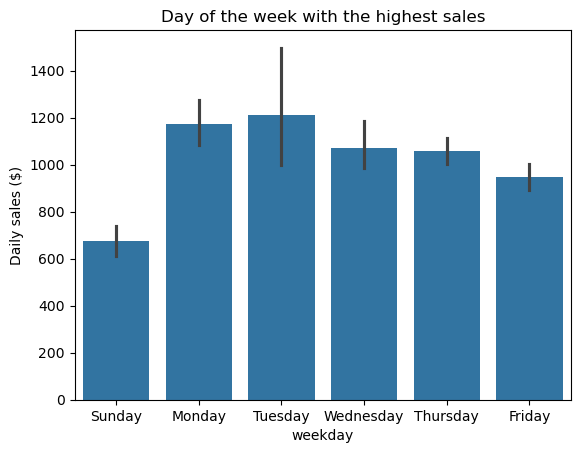

In [6]:
print(df.groupby("weekday")["daily_sales"].sum())

sns.barplot(data=df, x="weekday", y="daily_sales", estimator="mean")
plt.title("Day of the week with the highest sales")
plt.xlabel("weekday")
plt.ylabel("Daily sales ($)")
plt.show()

## Sales Trend 2023-2026
Daily sales plotted over time to visualize the overall trend and identify anomalies.

**Key finding:** A visible gap exists between January and July 2024 due to missing records. Three extreme outliers were detected — two confirmed as data entry errors and corrected by cross-referencing physical records.

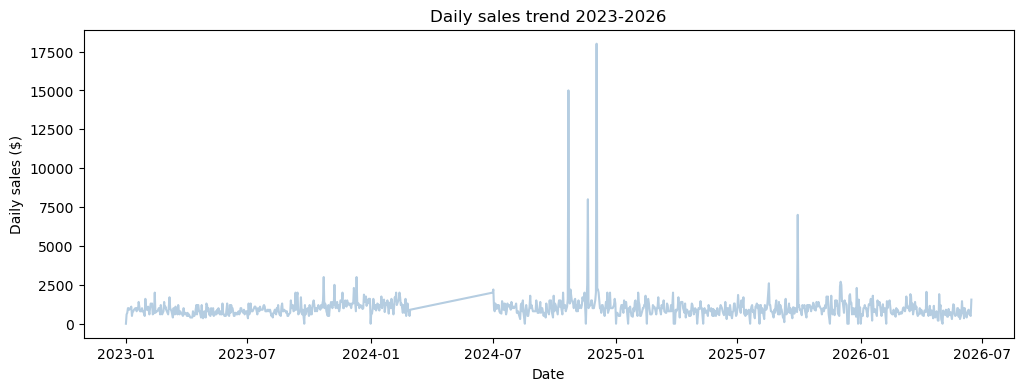

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["daily_sales"], alpha=0.4, color="steelblue")
plt.title("Daily sales trend 2023-2026")
plt.xlabel("Date")
plt.ylabel("Daily sales ($)")
plt.show()

## Fortnightly Analysis — Hypothesis Testing
The daily sales trend showed extreme peaks around late 2024. Given that the business is located in an oil industry zone where workers receive biweekly payments, i hypothesized that sales would be significantly higher during payday periods.

**Result:** No significant difference was found between the first and second fortnight. Both periods averaged approximately $1,020 per day, suggesting that the extreme peaks are driven by seasonal factors rather than a consistent payday effect.

         date  day  fortnight
0  2023-01-01    1          1
1  2023-01-02    2          1
2  2023-01-03    3          1
3  2023-01-04    4          1
4  2023-01-05    5          1
5  2023-01-06    6          1
7  2023-01-08    8          1
8  2023-01-09    9          1
9  2023-01-10   10          1
10 2023-01-11   11          1


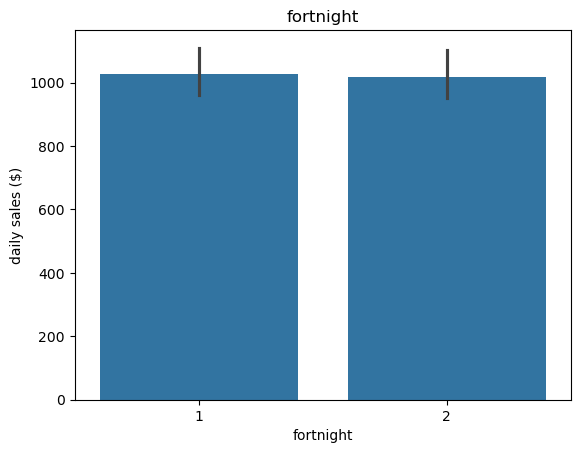

In [8]:
df["day"] = df["date"].dt.day
def assign_pay_period (x):
    if x<=15:
        return 1
    else:
        return 2
df["fortnight"]= df["day"].apply(assign_pay_period)
print(df[["date", "day", "fortnight"]].head(10))
sns.barplot(data=df, x="fortnight", y="daily_sales", estimator="mean")
plt.title("fortnight")
plt.xlabel("fortnight")
plt.ylabel("daily sales ($)")
plt.show()

## Outlier Detection
Using the IQR method to identify days with unusually high or low sales.

- Q1: $700 | Q3: $1,200 | IQR: $500
- Upper limit: $1,950 | Lower limit: -$50

**Result:** 32 days exceeded the upper limit. Two records ($15,000 - $18,000) were confirmed as data entry errors and corrected to $1,500 - $1,800 by cross-referencing physical records. The remaining outliers are concentrated in October-December, consistent with the seasonal pattern identified earlier.

In [9]:
#Outliers con Interquartile Range
Q1 = df["daily_sales"].quantile(0.25)
Q3 = df["daily_sales"].quantile(0.75)
IQR = Q3-Q1
lowerLimit = Q1-1.5 * IQR
upperLimit = Q3+1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper limit:", upperLimit)
print("Lower limit :", lowerLimit)

outliers = df[df["daily_sales"] > upperLimit]
print("Total outliers:", len(outliers))
print(outliers[["date", "daily_sales"]].sort_values("daily_sales", ascending=False)) 

# Correction of outliers confirmed as data entry errors
df.loc[df["date"] == "2024-12-03", "daily_sales"] = 1800
df.loc[df["date"] == "2024-10-22", "daily_sales"] = 1500
print(df[df["date"].isin(["2024-12-03", "2024-10-22"])][["date", "daily_sales"]]) 

outliers = df[df["daily_sales"] > upperLimit]
print("Total outliers:", len(outliers))
print(outliers[["date", "daily_sales"]].sort_values("daily_sales", ascending=False))

Q1: 700.0
Q3: 1200.0
IQR: 500.0
Upper limit: 1950.0
Lower limit : -50.0
Total outliers: 34
           date  daily_sales
580  2024-12-03      18000.0
538  2024-10-22      15000.0
567  2024-11-20       8000.0
880  2025-09-29       7000.0
295  2023-10-23       3000.0
344  2023-12-11       3000.0
944  2025-12-02       2700.0
837  2025-08-17       2600.0
566  2024-11-19       2500.0
311  2023-11-08       2500.0
945  2025-12-03       2500.0
943  2025-12-01       2400.0
340  2023-12-07       2300.0
968  2025-12-26       2300.0
426  2024-07-02       2200.0
541  2024-10-25       2200.0
582  2024-12-05       2200.0
581  2024-12-04       2200.0
1072 2026-04-09       2050.0
579  2024-12-02       2000.0
253  2023-09-11       2000.0
562  2024-11-15       2000.0
583  2024-12-06       2000.0
596  2024-12-19       2000.0
600  2024-12-23       2000.0
642  2025-02-03       2000.0
694  2025-03-27       2000.0
530  2024-10-14       2000.0
425  2024-07-01       2000.0
408  2024-02-13       2000.0
403  2024-

C:\Users\Gali\AppData\Local\Temp\ipykernel_424\3356428387.py:21: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  print(df[df["date"].isin(["2024-12-03", "2024-10-22"])][["date", "daily_sales"]])


## Monthly Sales Heatmap
Average daily sales by month and year to visualize seasonal patterns across the entire period.

**Key finding:** November 2024 was the strongest month in the entire dataset with an average of $1,532 per day. The missing data gap (March-June 2024) is clearly visible. The end-of-year pattern is consistent across all years.

month           1       2            3           4           5           6   \
year                                                                          
2023    870.370370   962.5   825.925926  652.000000  774.074074  788.461538   
2024   1090.740741  1212.0          NaN         NaN         NaN         NaN   
2025    868.518519  1025.0   957.692308  944.230769  803.846154  815.384615   
2026    976.923077   862.5  1001.851852  815.384615  665.384615  807.692308   

month           7           8            9            10           11  \
year                                                                    
2023    926.384615  774.074074  1008.000000  1059.259259  1280.769231   
2024   1120.370370  925.000000   938.461538  1259.259259  1532.000000   
2025    966.666667  978.846154  1107.692308  1055.555556  1032.000000   
2026           NaN         NaN          NaN          NaN          NaN   

month           12  
year                
2023   1404.423077  
2024   1314.814815  
20

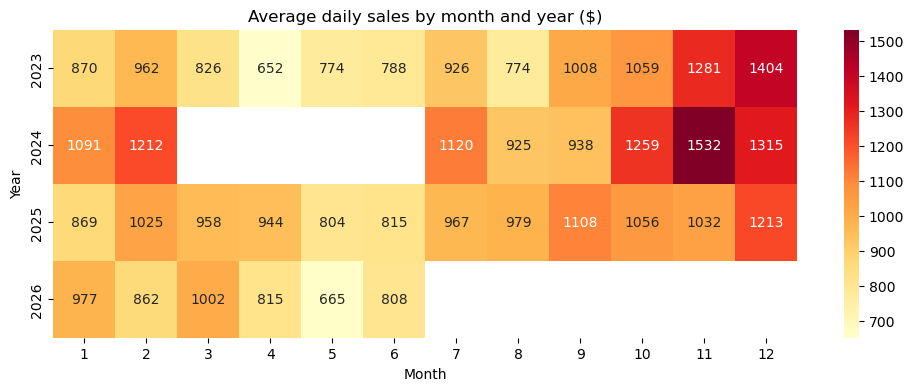

In [10]:
heatmap_data = df.pivot_table (values= "daily_sales",
                                index= "year",
                                columns= "month",
                                aggfunc= "mean"
                                )
print(heatmap_data)
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Average daily sales by month and year ($)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

## Year-over-Year Monthly Comparison
Average daily sales by month, broken down by year, to identify growth or decline patterns.

**Key finding:** 2024 consistently outperforms other years in the months with available data. All years follow the same seasonal pattern, confirming that the business has a predictable sales cycle. The owner confirmed that sales in previous years (before 2023) were higher, coinciding with a period of stronger economic activity in the oil industry zone. Additionally, a second branch was opened in August-September 2025, which may have redistributed part of the customer base.

   year  month  daily_sales
0  2023      1   870.370370
1  2023      2   962.500000
2  2023      3   825.925926
3  2023      4   652.000000
4  2023      5   774.074074
5  2023      6   788.461538
6  2023      7   926.384615
7  2023      8   774.074074
8  2023      9  1008.000000
9  2023     10  1059.259259


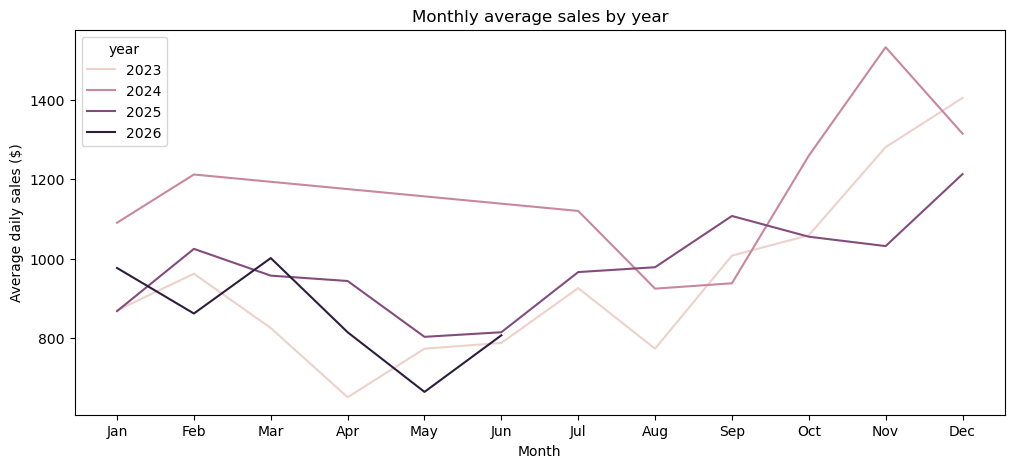

In [11]:
monthly_avg = df.groupby(["year", "month"])["daily_sales"].mean().reset_index()
print(monthly_avg.head(10))
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_avg, x="month", y="daily_sales", hue="year")
plt.title("Monthly average sales by year")
plt.xlabel("Month")
plt.ylabel("Average daily sales ($)")
plt.xticks(range(1, 13), ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.show()

## Sunday Performance Analysis
Comparison of average sales on open Sundays versus other weekdays.

**Key finding:** Out of 163 Sundays in the dataset, 148 were open for business. However, open Sundays generate 30% less revenue on average ($743) compared to other days ($1,055). This suggests that Sunday operations may not be cost-effective depending on operating expenses.

Total Sundays: 163
Sunday with $0: 15
Sundays with sales: 148
Average Sundays open: 743.58
Average other days: 1055.89


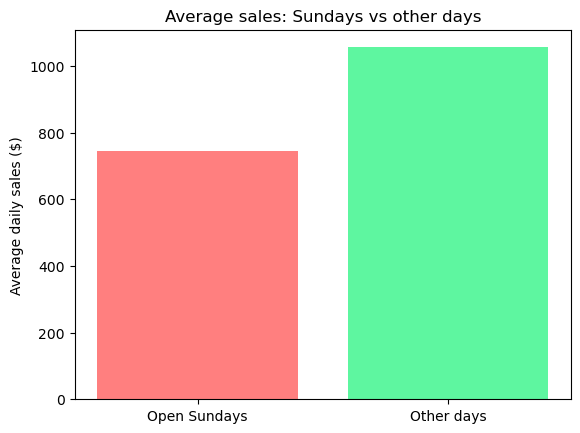

In [12]:
#sales on sundays
sundays = df[df["weekday"] == "Sunday"]
print("Total Sundays:", len(sundays))
print("Sunday with $0:", len(sundays[sundays["daily_sales"] == 0]))
print("Sundays with sales:", len(sundays[sundays["daily_sales"] > 0]))

#average sales on Sundays compared to other days
open_sundays= sundays[sundays["daily_sales"]>0]["daily_sales"].mean()
other_days = df[df["weekday"] != "Sunday"]["daily_sales"].mean()
print("Average Sundays open:", round(open_sundays, 2))
print("Average other days:", round(other_days, 2))

fig, ax = plt.subplots()
ax.bar(["Open Sundays", "Other days"], [open_sundays, other_days], color=["#FF7F7F", "#5EF6A0"])
ax.set_title("Average sales: Sundays vs other days")
ax.set_ylabel("Average daily sales ($)")
plt.show()

## Key Findings

1. **Seasonality:** October, November and December are consistently the strongest months. April and May are the weakest.
2. **Best year:** 2025 had the highest total sales. 2024 had the highest daily average in available months.
3. **Best days:** Monday and Tuesday generate the most revenue, likely related to nearby student activity.
4. **Sunday performance:** Open Sundays generate 30% less than other days ($743 vs $1,055).
5. **Outliers:** 2 data entry errors were detected and corrected. Remaining peaks concentrate in end-of-year season.
6. **Business context:** Located in an oil industry zone (PEMEX area). A second branch opened in August-September 2025 may have redistributed part of the demand.
7. **Fortnightly hypothesis:** No significant difference found between first and second fortnight sales.